In [1]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


PARTIE 1 — Installation

In [2]:
!pip install ultralytics
!pip install torchmetrics
!pip install opencv-python
!pip install tqdm
!pip install pytorch-optimizer


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 20.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.8/300.8 kB 12.7 MB/s eta 0:00:00


PARTIE 2 — Import

In [3]:
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import time
import os

from torch.utils.data import DataLoader
from tqdm import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"

print(device)

cuda


PARTIE 3 — Télécharger Pascal VOC

In [4]:
import torchvision.datasets as datasets
import torchvision.transforms as T


transform = T.Compose([
    T.ToTensor()
])


train_dataset = datasets.VOCDetection(
    root="./data",
    year="2012",
    image_set="train",
    download=True,
    transform=transform
)


val_dataset = datasets.VOCDetection(
    root="./data",
    year="2012",
    image_set="val",
    download=True,
    transform=transform
)


print(len(train_dataset))
print(len(val_dataset))

100%|██████████| 2.00G/2.00G [01:15<00:00, 26.6MB/s]


5717
5823


PARTIE 4 — Créer un SUBSET rapide GPU

In [5]:
from torch.utils.data import Subset

train_size = 1000
val_size = 200


train_dataset = Subset(
    train_dataset,
    range(train_size)
)


val_dataset = Subset(
    val_dataset,
    range(val_size)
)


print(len(train_dataset))
print(len(val_dataset))

1000
200


PARTIE 5 — YOLOv8n

In [6]:
import os

folders=[
"results/yolo",
"results/fasterrcnn",
"results/graphs",
"results/models"
]


for f in folders:
    os.makedirs(f,exist_ok=True)

print("folders created")

folders created


In [7]:
import os

print(os.getcwd())

/content


In [8]:
from ultralytics import YOLO
from pathlib import Path
import time
import pandas as pd
import os
import torch

# Ultralytics natively supports: SGD, Adam, AdamW, NAdam, RAdam, RMSProp, auto.
# Ranger is not a native Ultralytics optimizer, so for the YOLO (one-stage)
# side we compare SGD, AdamW, RMSProp and NAdam. Ranger is evaluated on the
# Faster R-CNN (two-stage) side, where we control the training loop directly.
optimizers = [
    "SGD",
    "AdamW",
    "RMSProp",
    "NAdam"
]

yolo_results = {}


def train_yolo(opt):

    print(f"\n========== YOLOv8n + {opt} ==========")

    model = YOLO("yolov8n.pt")

    # Reset GPU peak-memory counter so we measure THIS run only
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

    start = time.time()

    train_results = model.train(
        data="VOC.yaml",
        epochs=3,
        imgsz=416,
        batch=16,
        optimizer=opt,
        device=0,
        project="results/yolo",
        name=opt,
        exist_ok=True,
        verbose=True
    )

    training_time = time.time() - start

    # -----------------------
    # Peak GPU memory used during training (MB)
    # -----------------------
    if torch.cuda.is_available():
        gpu_mem_mb = torch.cuda.max_memory_allocated() / (1024 ** 2)
    else:
        gpu_mem_mb = 0.0

    # -----------------------
    # Evaluation
    # -----------------------

    metrics = model.val()

    # -----------------------
    # FPS
    # -----------------------

    start = time.time()

    model.predict(
        source="/content/datasets/VOC/images/test2007",
        imgsz=416,
        device=0,
        verbose=False
    )

    inference_time = time.time() - start

    # nombre d'images du dossier test2007
    nb_images = len(list(Path("/content/datasets/VOC/images/test2007").glob("*.jpg")))

    fps = nb_images / inference_time

    # -----------------------
    # Lecture automatique du results.csv
    # -----------------------

    save_dir = Path(train_results.save_dir)

    csv_file = save_dir / "results.csv"

    if not csv_file.exists():
        raise FileNotFoundError(f"results.csv introuvable : {csv_file}")

    losses = pd.read_csv(csv_file)

    final_loss = (
        losses["train/box_loss"].iloc[-1]
        + losses["train/cls_loss"].iloc[-1]
        + losses["train/dfl_loss"].iloc[-1]
    )

    yolo_results[opt] = {

        "Optimizer": opt,

        "mAP50": metrics.box.map50,

        "mAP50-95": metrics.box.map,

        "Precision": metrics.box.mp,

        "Recall": metrics.box.mr,

        "Training_Time": training_time,

        "FPS": fps,

        "GPU_Mem_MB": gpu_mem_mb,

        "Final_Loss": final_loss,

        "Loss_Curve": losses

    }


# =====================================
# Entraînement des 3 optimiseurs
# =====================================

for opt in optimizers:
    train_yolo(opt)

# =====================================
# Tableau final
# =====================================

yolo_final = pd.DataFrame([
    {
        k: v
        for k, v in result.items()
        if k != "Loss_Curve"
    }
    for result in yolo_results.values()
])

os.makedirs("results/yolo", exist_ok=True)

yolo_final.to_csv(
    "results/yolo/yolo_final_comparison.csv",
    index=False
)

print("\nYOLO comparison completed.\n")

yolo_final

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

========== YOLOv8n + SGD ==========
New https://pypi.org/project/ultralytics/8.4.88 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.87 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=VOC.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=3, erasin

,Optimizer,mAP50,mAP50-95,Precision,Recall,Training_Time,FPS,GPU_Mem_MB,Final_Loss
0,SGD,0.624859,0.419519,0.659362,0.576700,776.774518,91.728464,873.736328,4.07216
1,AdamW,0.341731,0.202569,0.403388,0.395641,677.505453,96.323254,875.706055,5.14233
2,RMSProp,0.628183,0.425988,0.656567,0.587054,682.794777,97.607824,865.193848,4.14988
3,NAdam,0.399138,0.242616,0.463546,0.417670,678.267505,98.951932,876.591309,4.91447


In [9]:
yolo_final = pd.DataFrame([
    {
        k: v
        for k, v in result.items()
        if k != "Loss_Curve"
    }
    for result in yolo_results.values()
])

yolo_final.to_csv(
    "results/yolo/yolo_final_comparison.csv",
    index=False
)

yolo_final

,Optimizer,mAP50,mAP50-95,Precision,Recall,Training_Time,FPS,GPU_Mem_MB,Final_Loss
0,SGD,0.624859,0.419519,0.659362,0.576700,776.774518,91.728464,873.736328,4.07216
1,AdamW,0.341731,0.202569,0.403388,0.395641,677.505453,96.323254,875.706055,5.14233
2,RMSProp,0.628183,0.425988,0.656567,0.587054,682.794777,97.607824,865.193848,4.14988
3,NAdam,0.399138,0.242616,0.463546,0.417670,678.267505,98.951932,876.591309,4.91447


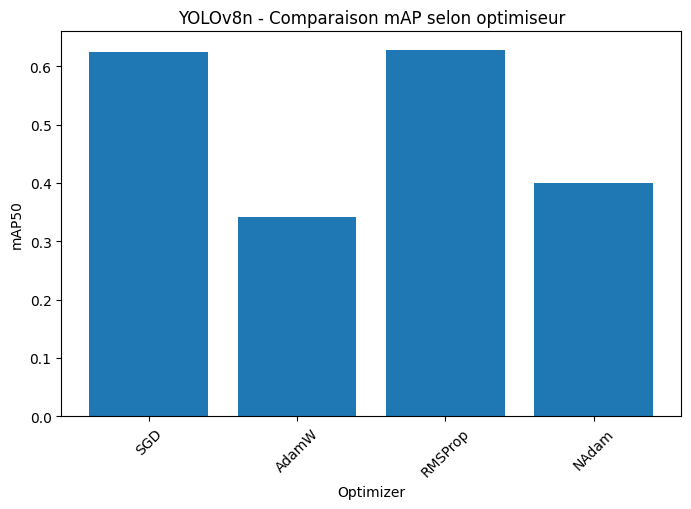

In [10]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8,5))


plt.bar(
yolo_final["Optimizer"],
yolo_final["mAP50"]
)


plt.title("YOLOv8n - Comparaison mAP selon optimiseur")

plt.xlabel("Optimizer")

plt.ylabel("mAP50")


plt.xticks(rotation=45)

plt.show()

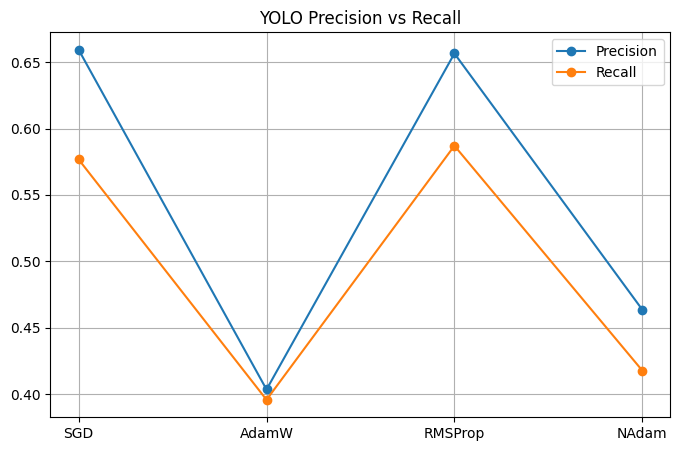

In [11]:
x=yolo_final["Optimizer"]


plt.figure(figsize=(8,5))


plt.plot(
x,
yolo_final["Precision"],
marker="o",
label="Precision"
)


plt.plot(
x,
yolo_final["Recall"],
marker="o",
label="Recall"
)


plt.title("YOLO Precision vs Recall")

plt.legend()

plt.grid()

plt.show()

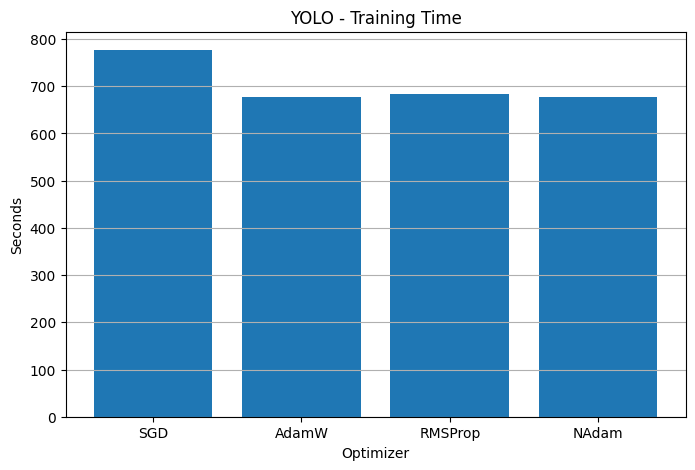

In [12]:
plt.figure(figsize=(8,5))

plt.bar(
    yolo_final["Optimizer"],
    yolo_final["Training_Time"]
)

plt.title("YOLO - Training Time")
plt.xlabel("Optimizer")
plt.ylabel("Seconds")
plt.grid(axis="y")
plt.show()

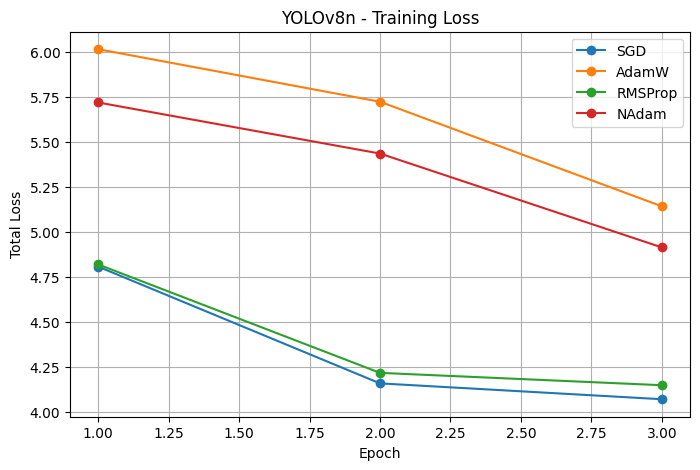

In [13]:
plt.figure(figsize=(8,5))

for opt in optimizers:

    losses = yolo_results[opt]["Loss_Curve"]

    plt.plot(
        losses["epoch"],
        losses["train/box_loss"]
        + losses["train/cls_loss"]
        + losses["train/dfl_loss"],
        marker="o",
        label=opt
    )

plt.title("YOLOv8n - Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Total Loss")
plt.legend()
plt.grid(True)
plt.show()

In [14]:
yolo_final.style.background_gradient(
subset=["mAP50","Precision","Recall"]
)

,Optimizer,mAP50,mAP50-95,Precision,Recall,Training_Time,FPS,GPU_Mem_MB,Final_Loss
0,SGD,0.624859,0.419519,0.659362,0.576700,776.774518,91.728464,873.736328,4.072160
1,AdamW,0.341731,0.202569,0.403388,0.395641,677.505453,96.323254,875.706055,5.142330
2,RMSProp,0.628183,0.425988,0.656567,0.587054,682.794777,97.607824,865.193848,4.149880
3,NAdam,0.399138,0.242616,0.463546,0.417670,678.267505,98.951932,876.591309,4.914470


Faster R-CNN

In [15]:
import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torchvision

from torch.utils.data import DataLoader, Subset

from torchvision.datasets import VOCDetection
from torchvision.models.detection import fasterrcnn_resnet50_fpn

In [16]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cuda


In [17]:
train_dataset_full = VOCDetection(
    root="./data",
    year="2012",
    image_set="train",
    download=True
)

val_dataset_full = VOCDetection(
    root="./data",
    year="2012",
    image_set="val",
    download=True
)

In [18]:
print(len(train_dataset_full))
print(len(val_dataset_full))

5717
5823


In [19]:
from torch.utils.data import Subset

train_size = 1000
val_size = 200

train_dataset = Subset(
    train_dataset_full,
    range(train_size)
)

val_dataset = Subset(
    val_dataset_full,
    range(val_size)
)

print(len(train_dataset))
print(len(val_dataset))

1000
200


In [20]:
from PIL import Image
from torchvision.transforms import functional as F

VOC_CLASSES = [
    "aeroplane","bicycle","bird","boat",
    "bottle","bus","car","cat","chair",
    "cow","diningtable","dog","horse",
    "motorbike","person","pottedplant",
    "sheep","sofa","train","tvmonitor"
]

CLASS_DICT = {
    name:i+1
    for i,name in enumerate(VOC_CLASSES)
}

In [21]:
class VOCDataset(torch.utils.data.Dataset):

    def __init__(self, subset):

        self.subset = subset

    def __len__(self):

        return len(self.subset)

    def __getitem__(self, idx):

        image, target = self.subset[idx]

        image = F.to_tensor(image)

        objects = target["annotation"]["object"]

        if not isinstance(objects, list):
            objects = [objects]

        boxes = []
        labels = []

        for obj in objects:

            bbox = obj["bndbox"]

            xmin = float(bbox["xmin"])
            ymin = float(bbox["ymin"])
            xmax = float(bbox["xmax"])
            ymax = float(bbox["ymax"])

            boxes.append(
                [xmin, ymin, xmax, ymax]
            )

            labels.append(
                CLASS_DICT[obj["name"]]
            )

        boxes = torch.tensor(
            boxes,
            dtype=torch.float32
        )

        labels = torch.tensor(
            labels,
            dtype=torch.int64
        )

        target = {
            "boxes": boxes,
            "labels": labels
        }

        return image, target

In [22]:
train_dataset = VOCDataset(train_dataset)

val_dataset = VOCDataset(val_dataset)

In [23]:
def collate_fn(batch):
    return tuple(zip(*batch))

In [24]:
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    collate_fn=collate_fn
)

In [25]:
images, targets = next(iter(train_loader))

print(len(images))
print(targets[0].keys())

4
dict_keys(['boxes', 'labels'])


In [26]:
images, targets = next(iter(train_loader))

print(len(images))
print(targets[0].keys())
print(targets[0]["boxes"].shape)

4
dict_keys(['boxes', 'labels'])
torch.Size([12, 4])


In [27]:
import os

os.makedirs("results/fasterrcnn", exist_ok=True)

In [28]:
from torchvision.models.detection import fasterrcnn_resnet50_fpn

model = fasterrcnn_resnet50_fpn(weights="DEFAULT")

model.to(device)

print("Model loaded")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 114MB/s] 


Model loaded


In [29]:
images, targets = next(iter(train_loader))

images = [img.to(device) for img in images]

targets = [
    {k:v.to(device) for k,v in t.items()}
    for t in targets
]

model.train()

loss_dict = model(images, targets)

print(loss_dict)

{'loss_classifier': tensor(1.5293, device='cuda:0', grad_fn=<NllLossBackward0>), 'loss_box_reg': tensor(0.2451, device='cuda:0', grad_fn=<DivBackward0>), 'loss_objectness': tensor(0.0111, device='cuda:0', grad_fn=<BinaryCrossEntropyWithLogitsBackward0>), 'loss_rpn_box_reg': tensor(0.0553, device='cuda:0', grad_fn=<DivBackward0>)}


In [30]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from pytorch_optimizer import Ranger


def _box_iou(boxes_a, boxes_b):
    """IoU matrix between two sets of xyxy boxes (tensors)."""
    if boxes_a.numel() == 0 or boxes_b.numel() == 0:
        return torch.zeros((boxes_a.shape[0], boxes_b.shape[0]))

    area_a = (boxes_a[:, 2] - boxes_a[:, 0]) * (boxes_a[:, 3] - boxes_a[:, 1])
    area_b = (boxes_b[:, 2] - boxes_b[:, 0]) * (boxes_b[:, 3] - boxes_b[:, 1])

    lt = torch.max(boxes_a[:, None, :2], boxes_b[None, :, :2])
    rb = torch.min(boxes_a[:, None, 2:], boxes_b[None, :, 2:])

    wh = (rb - lt).clamp(min=0)
    inter = wh[:, :, 0] * wh[:, :, 1]

    union = area_a[:, None] + area_b[None, :] - inter

    return inter / union.clamp(min=1e-6)


def evaluate_pr(model, loader, iou_thresh=0.5, score_thresh=0.5):
    """Precision & Recall for Faster R-CNN at a fixed IoU + confidence.

    A predicted box counts as a True Positive if it has confidence
    >= score_thresh and matches an unused ground-truth box of the same
    class with IoU >= iou_thresh. Extra predictions are False Positives;
    unmatched ground-truth boxes are False Negatives.
    """
    model.eval()

    tp = 0
    fp = 0
    fn = 0

    with torch.no_grad():

        for images, targets in loader:

            images = [img.to(device) for img in images]

            preds = model(images)

            for pred, target in zip(preds, targets):

                p_boxes = pred["boxes"].cpu()
                p_scores = pred["scores"].cpu()
                p_labels = pred["labels"].cpu()

                keep = p_scores >= score_thresh
                p_boxes = p_boxes[keep]
                p_labels = p_labels[keep]

                g_boxes = target["boxes"]
                g_labels = target["labels"]

                matched = set()

                for pb, pl in zip(p_boxes, p_labels):

                    best_iou = 0.0
                    best_j = -1

                    for j, (gb, gl) in enumerate(zip(g_boxes, g_labels)):

                        if j in matched:
                            continue
                        if pl.item() != gl.item():
                            continue

                        iou = _box_iou(pb[None, :], gb[None, :])[0, 0].item()

                        if iou > best_iou:
                            best_iou = iou
                            best_j = j

                    if best_iou >= iou_thresh and best_j >= 0:
                        tp += 1
                        matched.add(best_j)
                    else:
                        fp += 1

                fn += (len(g_boxes) - len(matched))

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0

    return {"Precision": precision, "Recall": recall}


def add_gaussian_noise(img, std=0.08):
    """Add gaussian noise to a [0,1] image tensor, clamp back to [0,1]."""
    noise = torch.randn_like(img) * std
    return (img + noise).clamp(0.0, 1.0)


class NoisyWrapper(torch.utils.data.Dataset):
    """Wraps a detection dataset and perturbs each image with noise."""

    def __init__(self, base, std=0.08):
        self.base = base
        self.std = std

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        image, target = self.base[idx]
        image = add_gaussian_noise(image, self.std)
        return image, target


def evaluate_map(model, loader=None):
    """Compute mAP@0.5 and mAP@0.5:0.95 on a loader (default val_loader)."""
    if loader is None:
        loader = val_loader

    model.eval()

    metric = MeanAveragePrecision(box_format="xyxy")

    with torch.no_grad():

        for images, targets in loader:

            images = [img.to(device) for img in images]

            preds = model(images)

            preds = [
                {k: v.to("cpu") for k, v in p.items()}
                for p in preds
            ]

            targets = [
                {k: v.to("cpu") for k, v in t.items()}
                for t in targets
            ]

            metric.update(preds, targets)

    result = metric.compute()

    return {
        "mAP50": float(result["map_50"]),
        "mAP50-95": float(result["map"])
    }


def train_frcnn(optimizer_name):

    model = fasterrcnn_resnet50_fpn(weights="DEFAULT")
    model.to(device)

    params = [p for p in model.parameters() if p.requires_grad]

    if optimizer_name == "SGD":

        optimizer = torch.optim.SGD(
            params,
            lr=0.005,
            momentum=0.9,
            weight_decay=0.0005
        )

    elif optimizer_name == "AdamW":

        optimizer = torch.optim.AdamW(
            params,
            lr=1e-4
        )

    elif optimizer_name == "RMSProp":

        optimizer = torch.optim.RMSprop(
            params,
            lr=1e-4
        )

    elif optimizer_name == "Ranger":

        optimizer = Ranger(
            params,
            lr=1e-4
        )

    else:
        raise ValueError(f"Optimiseur inconnu : {optimizer_name}")

    # Total loss per epoch + each component tracked separately.
    # Faster R-CNN returns a dict with:
    #   loss_classifier   -> classification loss  (ROI head)
    #   loss_box_reg      -> localization loss     (ROI head bbox regression)
    #   loss_objectness   -> objectness loss       (RPN)
    #   loss_rpn_box_reg  -> RPN bbox regression loss
    losses = []
    loss_components = {
        "loss_classifier": [],
        "loss_box_reg": [],
        "loss_objectness": [],
        "loss_rpn_box_reg": []
    }

    # Reset GPU peak-memory counter so we measure THIS run only
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

    start_time = time.time()

    for epoch in range(3):

        model.train()

        epoch_loss = 0.0
        epoch_components = {k: 0.0 for k in loss_components}

        for images, targets in train_loader:

            images = [img.to(device) for img in images]

            targets = [
                {k: v.to(device) for k, v in t.items()}
                for t in targets
            ]

            loss_dict = model(images, targets)

            loss = sum(loss for loss in loss_dict.values())

            optimizer.zero_grad()

            loss.backward()

            optimizer.step()

            epoch_loss += loss.item()

            for k in epoch_components:
                if k in loss_dict:
                    epoch_components[k] += loss_dict[k].item()

        n_batches = len(train_loader)

        epoch_loss /= n_batches
        losses.append(epoch_loss)

        for k in loss_components:
            loss_components[k].append(epoch_components[k] / n_batches)

        print(
            f"{optimizer_name} | Epoch {epoch+1}/3 | "
            f"Total = {epoch_loss:.4f} | "
            f"cls = {loss_components['loss_classifier'][-1]:.4f} | "
            f"box = {loss_components['loss_box_reg'][-1]:.4f} | "
            f"obj = {loss_components['loss_objectness'][-1]:.4f} | "
            f"rpn = {loss_components['loss_rpn_box_reg'][-1]:.4f}"
        )

    training_time = time.time() - start_time

    # -----------------------
    # Peak GPU memory used during training (MB)
    # -----------------------
    if torch.cuda.is_available():
        gpu_mem_mb = torch.cuda.max_memory_allocated() / (1024 ** 2)
    else:
        gpu_mem_mb = 0.0

    # -----------------------
    # Evaluation mAP (clean validation set)
    # -----------------------
    map_scores = evaluate_map(model, val_loader)

    # -----------------------
    # Precision & Recall (fixed IoU=0.5, confidence=0.5)
    # -----------------------
    pr_scores = evaluate_pr(model, val_loader)

    # -----------------------
    # Robustness: mAP on a gaussian-noise-perturbed validation set,
    # and the relative mAP50 drop vs clean.
    # -----------------------
    noisy_val = NoisyWrapper(val_dataset, std=0.08)
    noisy_loader = DataLoader(
        noisy_val,
        batch_size=4,
        shuffle=False,
        collate_fn=collate_fn
    )

    map_noisy = evaluate_map(model, noisy_loader)

    clean_map50 = map_scores["mAP50"]
    noisy_map50 = map_noisy["mAP50"]

    if clean_map50 > 0:
        robustness_drop_pct = 100.0 * (clean_map50 - noisy_map50) / clean_map50
    else:
        robustness_drop_pct = 0.0

    print(
        f"{optimizer_name} | mAP50 = {clean_map50:.4f} "
        f"| mAP50-95 = {map_scores['mAP50-95']:.4f} "
        f"| P = {pr_scores['Precision']:.4f} "
        f"| R = {pr_scores['Recall']:.4f} "
        f"| noisy mAP50 = {noisy_map50:.4f} "
        f"| drop = {robustness_drop_pct:.1f}% "
        f"| GPU = {gpu_mem_mb:.0f} MB"
    )

    return {
        "model": model,
        "losses": losses,
        "loss_components": loss_components,
        "training_time": training_time,
        "gpu_mem_mb": gpu_mem_mb,
        "mAP50": clean_map50,
        "mAP50-95": map_scores["mAP50-95"],
        "Precision": pr_scores["Precision"],
        "Recall": pr_scores["Recall"],
        "mAP50_noisy": noisy_map50,
        "Robustness_Drop_%": robustness_drop_pct
    }


In [31]:
def measure_fps(model):

    model.eval()

    total_images = 0

    start = time.time()

    with torch.no_grad():

        for images, _ in val_loader:

            images = [img.to(device) for img in images]

            _ = model(images)

            total_images += len(images)

    total_time = time.time() - start

    fps = total_images / total_time

    return fps

In [32]:
# Entrainement avec SGD
sgd = train_frcnn("SGD")

model_sgd = sgd["model"]
losses_sgd = sgd["losses"]
components_sgd = sgd["loss_components"]
train_time_sgd = sgd["training_time"]
gpu_sgd = sgd["gpu_mem_mb"]
map50_sgd = sgd["mAP50"]
map5095_sgd = sgd["mAP50-95"]
prec_sgd = sgd["Precision"]
rec_sgd = sgd["Recall"]
robust_sgd = sgd["Robustness_Drop_%"]

fps_sgd = measure_fps(model_sgd)

print(f"FPS : {fps_sgd:.2f}")
print(f"Training Time : {train_time_sgd:.2f} s")
print(f"Final Loss : {losses_sgd[-1]:.4f}")
print(f"GPU Memory : {gpu_sgd:.0f} MB")
print(f"mAP50 : {map50_sgd:.4f}")
print(f"mAP50-95 : {map5095_sgd:.4f}")
print(f"Precision : {prec_sgd:.4f}")
print(f"Recall : {rec_sgd:.4f}")
print(f"Robustness mAP50 drop : {robust_sgd:.1f} %")


SGD | Epoch 1/3 | Total = 0.4740 | cls = 0.2624 | box = 0.1773 | obj = 0.0144 | rpn = 0.0198
SGD | Epoch 2/3 | Total = 0.3005 | cls = 0.1309 | box = 0.1463 | obj = 0.0068 | rpn = 0.0165
SGD | Epoch 3/3 | Total = 0.2388 | cls = 0.0922 | box = 0.1267 | obj = 0.0044 | rpn = 0.0155
SGD | mAP50 = 0.6067 | mAP50-95 = 0.3517 | P = 0.5893 | R = 0.7673 | noisy mAP50 = 0.4869 | drop = 19.8% | GPU = 11280 MB
FPS : 6.57
Training Time : 1021.25 s
Final Loss : 0.2388
GPU Memory : 11280 MB
mAP50 : 0.6067
mAP50-95 : 0.3517
Precision : 0.5893
Recall : 0.7673
Robustness mAP50 drop : 19.8 %


In [33]:
adamw = train_frcnn("AdamW")

model_adamw = adamw["model"]
losses_adamw = adamw["losses"]
components_adamw = adamw["loss_components"]
train_time_adamw = adamw["training_time"]
gpu_adamw = adamw["gpu_mem_mb"]
map50_adamw = adamw["mAP50"]
map5095_adamw = adamw["mAP50-95"]
prec_adamw = adamw["Precision"]
rec_adamw = adamw["Recall"]
robust_adamw = adamw["Robustness_Drop_%"]

fps_adamw = measure_fps(model_adamw)

print(f"FPS : {fps_adamw:.2f}")
print(f"Training Time : {train_time_adamw:.2f} s")
print(f"Final Loss : {losses_adamw[-1]:.4f}")
print(f"GPU Memory : {gpu_adamw:.0f} MB")
print(f"mAP50 : {map50_adamw:.4f}")
print(f"mAP50-95 : {map5095_adamw:.4f}")
print(f"Precision : {prec_adamw:.4f}")
print(f"Recall : {rec_adamw:.4f}")
print(f"Robustness mAP50 drop : {robust_adamw:.1f} %")


AdamW | Epoch 1/3 | Total = 0.4901 | cls = 0.2607 | box = 0.1874 | obj = 0.0204 | rpn = 0.0217
AdamW | Epoch 2/3 | Total = 0.3550 | cls = 0.1622 | box = 0.1640 | obj = 0.0098 | rpn = 0.0190
AdamW | Epoch 3/3 | Total = 0.2951 | cls = 0.1248 | box = 0.1456 | obj = 0.0067 | rpn = 0.0179
AdamW | mAP50 = 0.4277 | mAP50-95 = 0.2320 | P = 0.4558 | R = 0.6939 | noisy mAP50 = 0.2840 | drop = 33.6% | GPU = 11761 MB
FPS : 6.56
Training Time : 1015.31 s
Final Loss : 0.2951
GPU Memory : 11761 MB
mAP50 : 0.4277
mAP50-95 : 0.2320
Precision : 0.4558
Recall : 0.6939
Robustness mAP50 drop : 33.6 %


In [34]:
rms = train_frcnn("RMSProp")

model_rms = rms["model"]
losses_rms = rms["losses"]
components_rms = rms["loss_components"]
train_time_rms = rms["training_time"]
gpu_rms = rms["gpu_mem_mb"]
map50_rms = rms["mAP50"]
map5095_rms = rms["mAP50-95"]
prec_rms = rms["Precision"]
rec_rms = rms["Recall"]
robust_rms = rms["Robustness_Drop_%"]

fps_rms = measure_fps(model_rms)

print(f"FPS : {fps_rms:.2f}")
print(f"Training Time : {train_time_rms:.2f} s")
print(f"Final Loss : {losses_rms[-1]:.4f}")
print(f"GPU Memory : {gpu_rms:.0f} MB")
print(f"mAP50 : {map50_rms:.4f}")
print(f"mAP50-95 : {map5095_rms:.4f}")
print(f"Precision : {prec_rms:.4f}")
print(f"Recall : {rec_rms:.4f}")
print(f"Robustness mAP50 drop : {robust_rms:.1f} %")


RMSProp | Epoch 1/3 | Total = 0.6334 | cls = 0.3304 | box = 0.1932 | obj = 0.0790 | rpn = 0.0309
RMSProp | Epoch 2/3 | Total = 0.4859 | cls = 0.2520 | box = 0.1862 | obj = 0.0241 | rpn = 0.0236
RMSProp | Epoch 3/3 | Total = 0.4129 | cls = 0.2047 | box = 0.1729 | obj = 0.0146 | rpn = 0.0206
RMSProp | mAP50 = 0.3056 | mAP50-95 = 0.1588 | P = 0.3695 | R = 0.6041 | noisy mAP50 = 0.2298 | drop = 24.8% | GPU = 11936 MB
FPS : 6.57
Training Time : 1004.81 s
Final Loss : 0.4129
GPU Memory : 11936 MB
mAP50 : 0.3056
mAP50-95 : 0.1588
Precision : 0.3695
Recall : 0.6041
Robustness mAP50 drop : 24.8 %


In [35]:
ranger = train_frcnn("Ranger")

model_ranger = ranger["model"]
losses_ranger = ranger["losses"]
components_ranger = ranger["loss_components"]
train_time_ranger = ranger["training_time"]
gpu_ranger = ranger["gpu_mem_mb"]
map50_ranger = ranger["mAP50"]
map5095_ranger = ranger["mAP50-95"]
prec_ranger = ranger["Precision"]
rec_ranger = ranger["Recall"]
robust_ranger = ranger["Robustness_Drop_%"]

fps_ranger = measure_fps(model_ranger)

print(f"FPS : {fps_ranger:.2f}")
print(f"Training Time : {train_time_ranger:.2f} s")
print(f"Final Loss : {losses_ranger[-1]:.4f}")
print(f"GPU Memory : {gpu_ranger:.0f} MB")
print(f"mAP50 : {map50_ranger:.4f}")
print(f"mAP50-95 : {map5095_ranger:.4f}")
print(f"Precision : {prec_ranger:.4f}")
print(f"Recall : {rec_ranger:.4f}")
print(f"Robustness mAP50 drop : {robust_ranger:.1f} %")


Ranger | Epoch 1/3 | Total = 0.6648 | cls = 0.4497 | box = 0.1864 | obj = 0.0117 | rpn = 0.0169
Ranger | Epoch 2/3 | Total = 0.3305 | cls = 0.1654 | box = 0.1436 | obj = 0.0063 | rpn = 0.0152
Ranger | Epoch 3/3 | Total = 0.2343 | cls = 0.0982 | box = 0.1189 | obj = 0.0036 | rpn = 0.0137
Ranger | mAP50 = 0.6281 | mAP50-95 = 0.3928 | P = 0.6351 | R = 0.7531 | noisy mAP50 = 0.4886 | drop = 22.2% | GPU = 12570 MB
FPS : 6.56
Training Time : 1020.03 s
Final Loss : 0.2343
GPU Memory : 12570 MB
mAP50 : 0.6281
mAP50-95 : 0.3928
Precision : 0.6351
Recall : 0.7531
Robustness mAP50 drop : 22.2 %


In [36]:
%whos

Variable                  Type            Data/Info
---------------------------------------------------
CLASS_DICT                dict            n=20
DataLoader                type            <class 'torch.utils.data.dataloader.DataLoader'>
F                         module          <module 'torchvision.tran<...>ransforms/functional.py'>
Image                     module          <module 'PIL.Image' from <...>t-packages/PIL/Image.py'>
MeanAveragePrecision      ABCMeta         <class 'torchmetrics.dete<...>ap.MeanAveragePrecision'>
NoisyWrapper              type            <class '__main__.NoisyWrapper'>
Path                      type            <class 'pathlib.Path'>
Ranger                    ABCMeta         <class 'pytorch_optimizer<...>optimizer.ranger.Ranger'>
Subset                    type            <class 'torch.utils.data.dataset.Subset'>
T                         module          <module 'torchvision.tran<...>/transforms/__init__.py'>
VOCDataset                type            <cl

In [37]:
results = pd.DataFrame({

    "Optimizer": [
        "SGD",
        "AdamW",
        "RMSProp",
        "Ranger"
    ],

    "mAP50": [
        map50_sgd,
        map50_adamw,
        map50_rms,
        map50_ranger
    ],

    "mAP50-95": [
        map5095_sgd,
        map5095_adamw,
        map5095_rms,
        map5095_ranger
    ],

    "Precision": [
        prec_sgd,
        prec_adamw,
        prec_rms,
        prec_ranger
    ],

    "Recall": [
        rec_sgd,
        rec_adamw,
        rec_rms,
        rec_ranger
    ],

    "Final_Loss": [
        losses_sgd[-1],
        losses_adamw[-1],
        losses_rms[-1],
        losses_ranger[-1]
    ],

    "Training_Time": [
        train_time_sgd,
        train_time_adamw,
        train_time_rms,
        train_time_ranger
    ],

    "FPS": [
        fps_sgd,
        fps_adamw,
        fps_rms,
        fps_ranger
    ],

    "GPU_Mem_MB": [
        gpu_sgd,
        gpu_adamw,
        gpu_rms,
        gpu_ranger
    ],

    "Robustness_Drop_%": [
        robust_sgd,
        robust_adamw,
        robust_rms,
        robust_ranger
    ]

})

results = results.round(4)

results


,Optimizer,mAP50,mAP50-95,Precision,Recall,Final_Loss,Training_Time,FPS,GPU_Mem_MB,Robustness_Drop_%
0,SGD,0.6067,0.3517,0.5893,0.7673,0.2388,1021.2486,6.5661,11280.0869,19.7581
1,AdamW,0.4277,0.2320,0.4558,0.6939,0.2951,1015.3119,6.5598,11761.1343,33.5919
2,RMSProp,0.3056,0.1588,0.3695,0.6041,0.4129,1004.8127,6.5727,11935.8594,24.8147
3,Ranger,0.6281,0.3928,0.6351,0.7531,0.2343,1020.0261,6.5558,12569.7812,22.2085


In [38]:
results.to_csv(
    "results/fasterrcnn/fasterrcnn_results.csv",
    index=False
)

print("Saved")

Saved


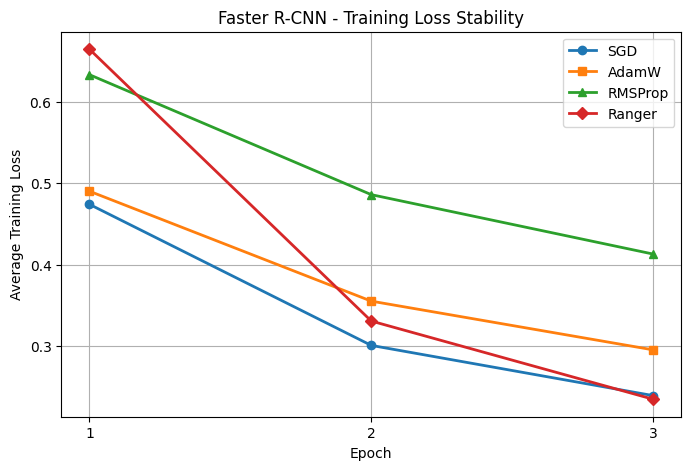

In [39]:
plt.figure(figsize=(8,5))

epochs = range(1, len(losses_sgd) + 1)

plt.plot(epochs, losses_sgd, marker='o', linewidth=2, label='SGD')
plt.plot(epochs, losses_adamw, marker='s', linewidth=2, label='AdamW')
plt.plot(epochs, losses_rms, marker='^', linewidth=2, label='RMSProp')
plt.plot(epochs, losses_ranger, marker='D', linewidth=2, label='Ranger')

plt.xlabel("Epoch")
plt.ylabel("Average Training Loss")
plt.title("Faster R-CNN - Training Loss Stability")

plt.xticks(epochs)

plt.legend()
plt.grid(True)

plt.show()


### Faster R-CNN - Stabilité des losses par composante

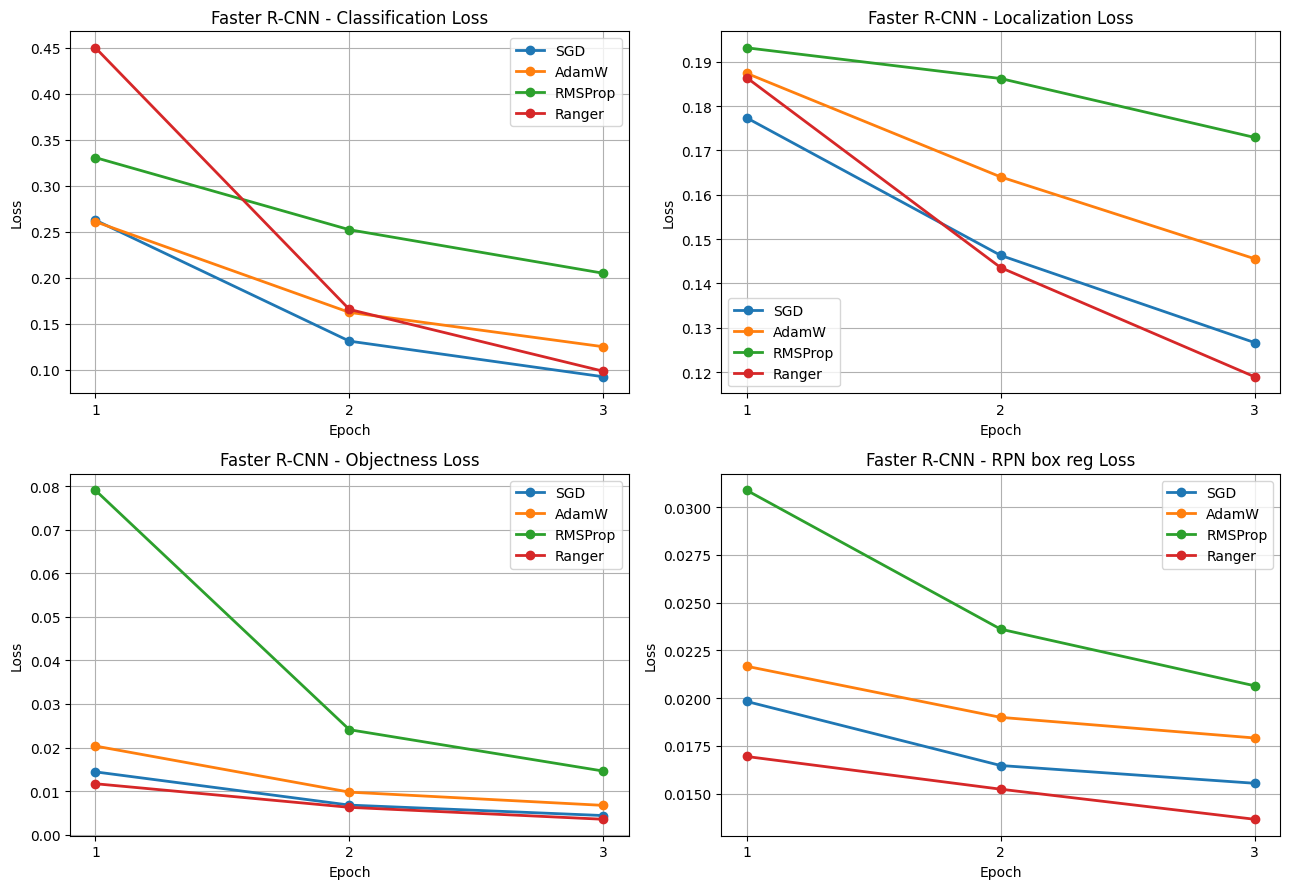

In [40]:
# Faster R-CNN - per-component loss stability
# Classification (loss_classifier) vs Localization (loss_box_reg)
# vs Objectness (loss_objectness) vs RPN box reg (loss_rpn_box_reg).
# This is what the subject asks to analyze: whether an optimizer
# stabilizes the classification loss and the localization loss.

components_by_opt = {
    "SGD": components_sgd,
    "AdamW": components_adamw,
    "RMSProp": components_rms,
    "Ranger": components_ranger
}

component_names = [
    ("loss_classifier", "Classification"),
    ("loss_box_reg", "Localization"),
    ("loss_objectness", "Objectness"),
    ("loss_rpn_box_reg", "RPN box reg")
]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.ravel()

for ax, (key, title) in zip(axes, component_names):

    for opt, comps in components_by_opt.items():

        epochs = range(1, len(comps[key]) + 1)

        ax.plot(
            epochs,
            comps[key],
            marker="o",
            linewidth=2,
            label=opt
        )

    ax.set_title(f"Faster R-CNN - {title} Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_xticks(list(epochs))
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()


In [41]:
import pandas as pd

frcnn_df = pd.DataFrame({

    "Optimizer": [
        "SGD",
        "AdamW",
        "RMSProp",
        "Ranger"
    ],

    "mAP50": [
        map50_sgd,
        map50_adamw,
        map50_rms,
        map50_ranger
    ],

    "mAP50-95": [
        map5095_sgd,
        map5095_adamw,
        map5095_rms,
        map5095_ranger
    ],

    "Precision": [
        prec_sgd,
        prec_adamw,
        prec_rms,
        prec_ranger
    ],

    "Recall": [
        rec_sgd,
        rec_adamw,
        rec_rms,
        rec_ranger
    ],

    "Final_Loss": [
        losses_sgd[-1],
        losses_adamw[-1],
        losses_rms[-1],
        losses_ranger[-1]
    ],

    "Training_Time": [
        train_time_sgd,
        train_time_adamw,
        train_time_rms,
        train_time_ranger
    ],

    "FPS": [
        fps_sgd,
        fps_adamw,
        fps_rms,
        fps_ranger
    ],

    "GPU_Mem_MB": [
        gpu_sgd,
        gpu_adamw,
        gpu_rms,
        gpu_ranger
    ],

    "Robustness_Drop_%": [
        robust_sgd,
        robust_adamw,
        robust_rms,
        robust_ranger
    ]

})

frcnn_df = frcnn_df.round(4)

frcnn_df


,Optimizer,mAP50,mAP50-95,Precision,Recall,Final_Loss,Training_Time,FPS,GPU_Mem_MB,Robustness_Drop_%
0,SGD,0.6067,0.3517,0.5893,0.7673,0.2388,1021.2486,6.5661,11280.0869,19.7581
1,AdamW,0.4277,0.2320,0.4558,0.6939,0.2951,1015.3119,6.5598,11761.1343,33.5919
2,RMSProp,0.3056,0.1588,0.3695,0.6041,0.4129,1004.8127,6.5727,11935.8594,24.8147
3,Ranger,0.6281,0.3928,0.6351,0.7531,0.2343,1020.0261,6.5558,12569.7812,22.2085


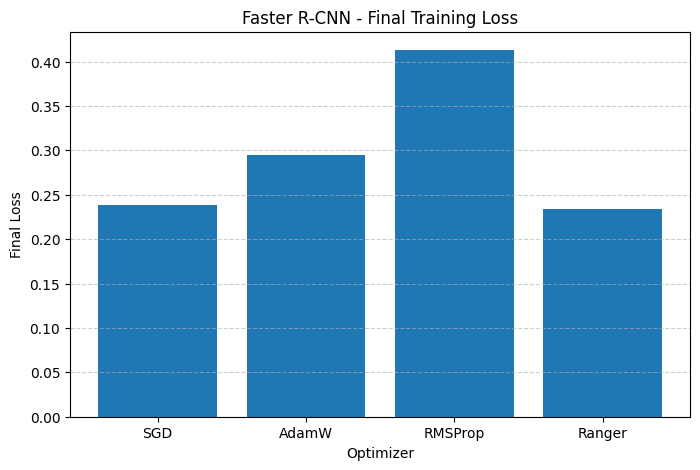

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    frcnn_df["Optimizer"],
    frcnn_df["Final_Loss"]
)

plt.title("Faster R-CNN - Final Training Loss")
plt.xlabel("Optimizer")
plt.ylabel("Final Loss")

plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()

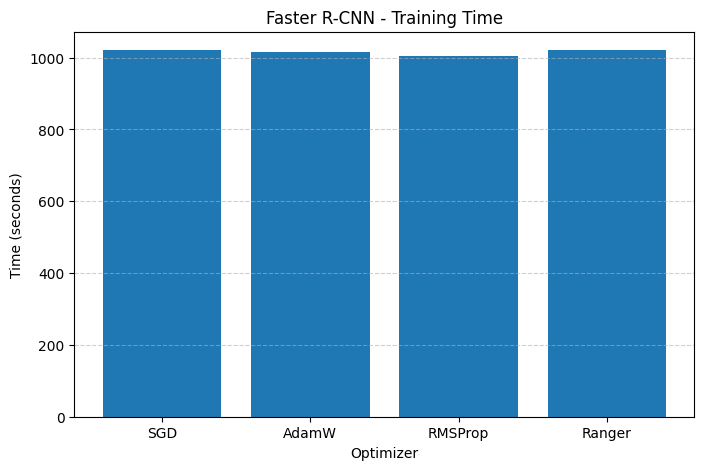

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    frcnn_df["Optimizer"],
    frcnn_df["Training_Time"]
)

plt.title("Faster R-CNN - Training Time")
plt.xlabel("Optimizer")
plt.ylabel("Time (seconds)")

plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()

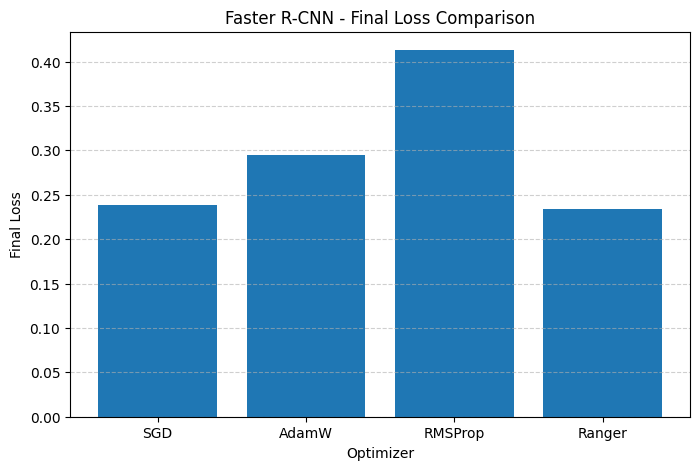

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    frcnn_df["Optimizer"],
    frcnn_df["Final_Loss"]
)

plt.title("Faster R-CNN - Final Loss Comparison")
plt.xlabel("Optimizer")
plt.ylabel("Final Loss")

plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()

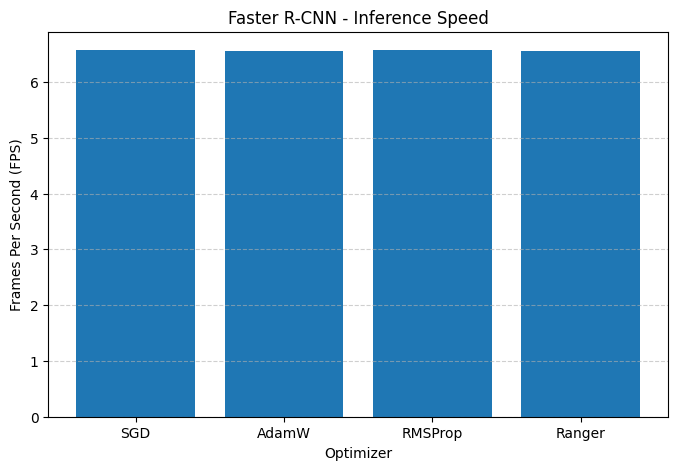

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    frcnn_df["Optimizer"],
    frcnn_df["FPS"]
)

plt.title("Faster R-CNN - Inference Speed")
plt.xlabel("Optimizer")
plt.ylabel("Frames Per Second (FPS)")

plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()

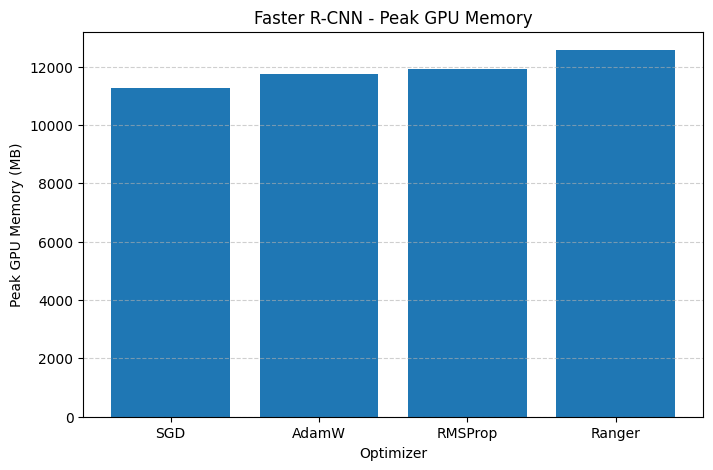

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    frcnn_df["Optimizer"],
    frcnn_df["GPU_Mem_MB"]
)

plt.title("Faster R-CNN - Peak GPU Memory")
plt.xlabel("Optimizer")
plt.ylabel("Peak GPU Memory (MB)")

plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()


### Faster R-CNN - Robustesse au bruit gaussien

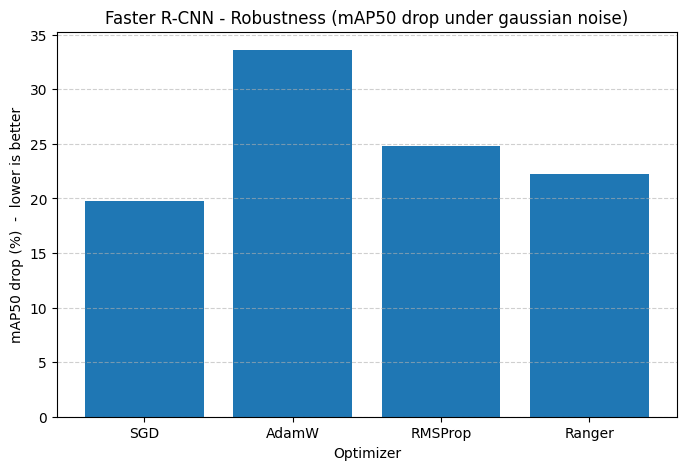

In [47]:
import matplotlib.pyplot as plt

# Robustness: relative mAP50 drop when the validation images are
# perturbed with gaussian noise. Lower drop = more robust optimizer.
plt.figure(figsize=(8,5))

plt.bar(
    frcnn_df["Optimizer"],
    frcnn_df["Robustness_Drop_%"]
)

plt.title("Faster R-CNN - Robustness (mAP50 drop under gaussian noise)")
plt.xlabel("Optimizer")
plt.ylabel("mAP50 drop (%)  -  lower is better")

plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()


COMPARAISON FINALE YOLO vs Faster R-CNN

In [48]:
import pandas as pd

yolo_df = pd.read_csv("results/yolo/yolo_final_comparison.csv")
frcnn_df = pd.read_csv("results/fasterrcnn/fasterrcnn_results.csv")

In [49]:
import pandas as pd

yolo_df = pd.read_csv("results/yolo/yolo_final_comparison.csv")
frcnn_df = pd.read_csv("results/fasterrcnn/fasterrcnn_results.csv")

yolo_df["Model"] = "YOLOv8n"
frcnn_df["Model"] = "Faster R-CNN"

# Colonnes communes aux deux familles de detecteurs.
# mAP est desormais disponible des deux cotes (YOLO via model.val(),
# Faster R-CNN via torchmetrics MeanAveragePrecision).
common_columns = [
    "Model",
    "Optimizer",
    "mAP50",
    "mAP50-95",
    "Precision",
    "Recall",
    "Final_Loss",
    "Training_Time",
    "FPS",
    "GPU_Mem_MB"
]
# NOTE: Robustness (mAP drop under gaussian noise) is evaluated only on the
# Faster R-CNN side, where we control the eval loop directly. It stays in
# frcnn_df and its own plot, and is intentionally NOT merged into final_df
# (YOLO's Ultralytics val pipeline would need a separate perturbed dataset).

final_df = pd.concat(
    [
        yolo_df[common_columns],
        frcnn_df[common_columns]
    ],
    ignore_index=True
)

final_df = final_df.round(4)

final_df


,Model,Optimizer,mAP50,mAP50-95,Precision,Recall,Final_Loss,Training_Time,FPS,GPU_Mem_MB
0,YOLOv8n,SGD,0.6249,0.4195,0.6594,0.5767,4.0722,776.7745,91.7285,873.7363
1,YOLOv8n,AdamW,0.3417,0.2026,0.4034,0.3956,5.1423,677.5055,96.3233,875.7061
2,YOLOv8n,RMSProp,0.6282,0.4260,0.6566,0.5871,4.1499,682.7948,97.6078,865.1938
3,YOLOv8n,NAdam,0.3991,0.2426,0.4635,0.4177,4.9145,678.2675,98.9519,876.5913
4,Faster R-CNN,SGD,0.6067,0.3517,0.5893,0.7673,0.2388,1021.2486,6.5661,11280.0869
5,Faster R-CNN,AdamW,0.4277,0.2320,0.4558,0.6939,0.2951,1015.3119,6.5598,11761.1343
6,Faster R-CNN,RMSProp,0.3056,0.1588,0.3695,0.6041,0.4129,1004.8127,6.5727,11935.8594
7,Faster R-CNN,Ranger,0.6281,0.3928,0.6351,0.7531,0.2343,1020.0261,6.5558,12569.7812


In [51]:
final_df.sort_values(["Model", "Optimizer"])

,Model,Optimizer,mAP50,mAP50-95,Precision,Recall,Final_Loss,Training_Time,FPS,GPU_Mem_MB
5,Faster R-CNN,AdamW,0.4277,0.2320,0.4558,0.6939,0.2951,1015.3119,6.5598,11761.1343
6,Faster R-CNN,RMSProp,0.3056,0.1588,0.3695,0.6041,0.4129,1004.8127,6.5727,11935.8594
7,Faster R-CNN,Ranger,0.6281,0.3928,0.6351,0.7531,0.2343,1020.0261,6.5558,12569.7812
4,Faster R-CNN,SGD,0.6067,0.3517,0.5893,0.7673,0.2388,1021.2486,6.5661,11280.0869
1,YOLOv8n,AdamW,0.3417,0.2026,0.4034,0.3956,5.1423,677.5055,96.3233,875.7061
3,YOLOv8n,NAdam,0.3991,0.2426,0.4635,0.4177,4.9145,678.2675,98.9519,876.5913
2,YOLOv8n,RMSProp,0.6282,0.4260,0.6566,0.5871,4.1499,682.7948,97.6078,865.1938
0,YOLOv8n,SGD,0.6249,0.4195,0.6594,0.5767,4.0722,776.7745,91.7285,873.7363


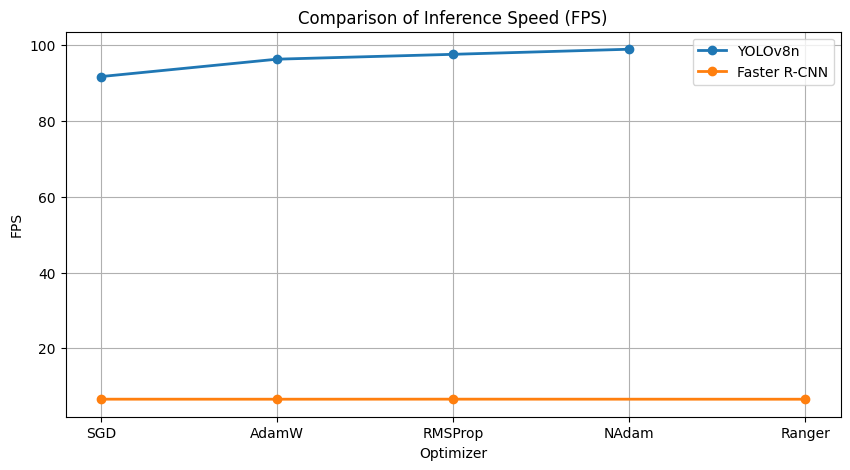

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for model in final_df["Model"].unique():

    data = final_df[final_df["Model"] == model]

    plt.plot(
        data["Optimizer"],
        data["FPS"],
        marker="o",
        linewidth=2,
        label=model
    )

plt.title("Comparison of Inference Speed (FPS)")
plt.xlabel("Optimizer")
plt.ylabel("FPS")
plt.legend()
plt.grid(True)

plt.show()

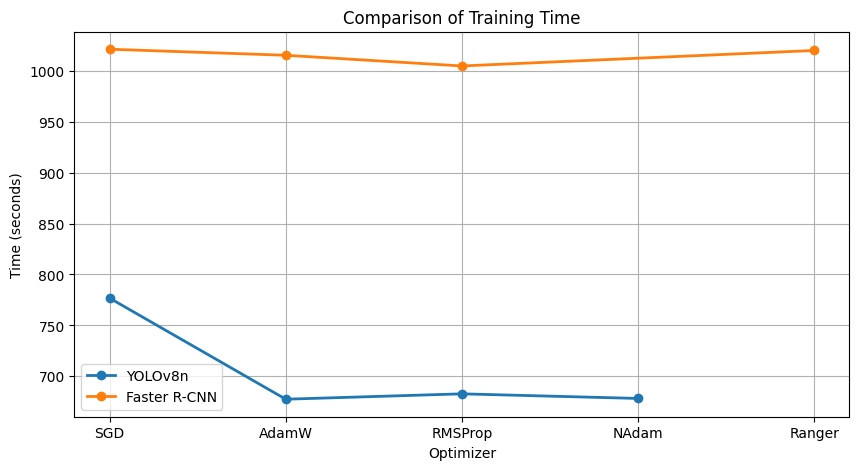

In [53]:
plt.figure(figsize=(10,5))

for model in final_df["Model"].unique():

    data = final_df[final_df["Model"] == model]

    plt.plot(
        data["Optimizer"],
        data["Training_Time"],
        marker="o",
        linewidth=2,
        label=model
    )

plt.title("Comparison of Training Time")
plt.xlabel("Optimizer")
plt.ylabel("Time (seconds)")
plt.legend()
plt.grid(True)

plt.show()

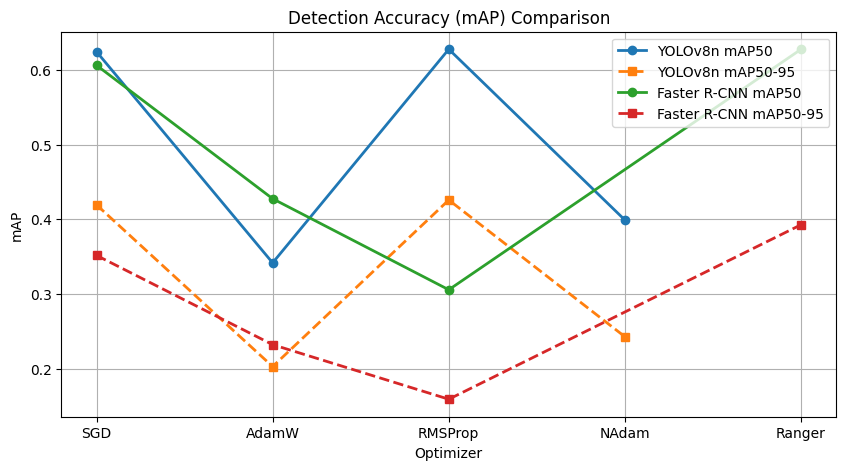

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for model in final_df["Model"].unique():

    data = final_df[final_df["Model"] == model]

    plt.plot(
        data["Optimizer"],
        data["mAP50"],
        marker="o",
        linewidth=2,
        label=f"{model} mAP50"
    )

    plt.plot(
        data["Optimizer"],
        data["mAP50-95"],
        marker="s",
        linestyle="--",
        linewidth=2,
        label=f"{model} mAP50-95"
    )

plt.title("Detection Accuracy (mAP) Comparison")
plt.xlabel("Optimizer")
plt.ylabel("mAP")

plt.legend()
plt.grid(True)

plt.show()


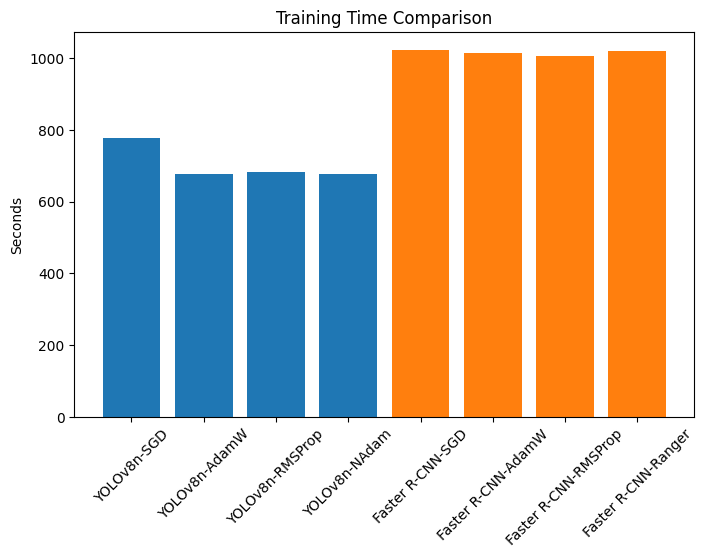

In [55]:
plt.figure(figsize=(8,5))

for model in final_df["Model"].unique():

    data = final_df[final_df["Model"] == model]

    plt.bar(
        [f"{model}-{opt}" for opt in data["Optimizer"]],
        data["Training_Time"],
        label=model
    )

plt.title("Training Time Comparison")
plt.xticks(rotation=45)
plt.ylabel("Seconds")
plt.show()

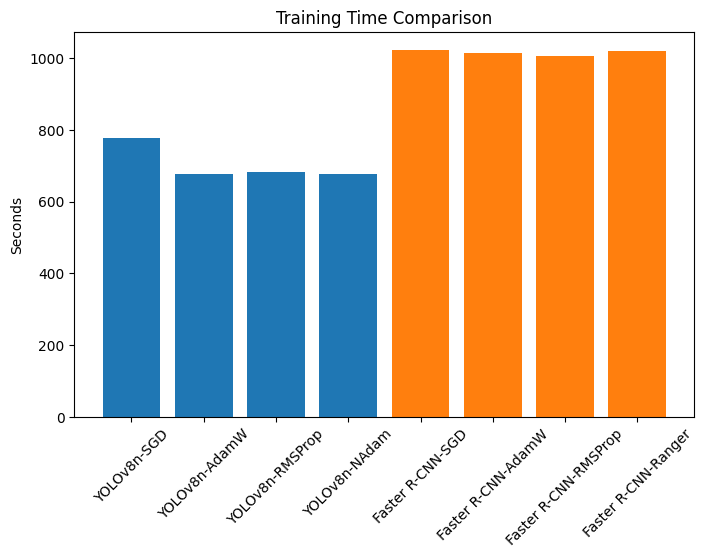

In [56]:
plt.figure(figsize=(8,5))

for model in final_df["Model"].unique():

    data = final_df[final_df["Model"] == model]

    plt.bar(
        [f"{model}-{opt}" for opt in data["Optimizer"]],
        data["Training_Time"],
        label=model
    )

plt.title("Training Time Comparison")
plt.xticks(rotation=45)
plt.ylabel("Seconds")
plt.show()

In [57]:
print("=== Best optimizer by model ===")

for model in final_df["Model"].unique():

    data = final_df[final_df["Model"] == model]

    best_map = data.loc[data["mAP50"].idxmax()]
    best_loss = data.loc[data["Final_Loss"].idxmin()]
    best_speed = data.loc[data["FPS"].idxmax()]
    best_time = data.loc[data["Training_Time"].idxmin()]

    print(f"\n{model}")
    print(f"Best mAP50        : {best_map['Optimizer']}")
    print(f"Lowest Loss       : {best_loss['Optimizer']}")
    print(f"Fastest Inference : {best_speed['Optimizer']}")
    print(f"Shortest Training : {best_time['Optimizer']}")


=== Best optimizer by model ===

YOLOv8n
Best mAP50        : RMSProp
Lowest Loss       : SGD
Fastest Inference : NAdam
Shortest Training : AdamW

Faster R-CNN
Best mAP50        : Ranger
Lowest Loss       : Ranger
Fastest Inference : RMSProp
Shortest Training : RMSProp


In [58]:
final_df.groupby("Model").mean(numeric_only=True)

,mAP50,mAP50-95,Precision,Recall,Final_Loss,Training_Time,FPS,GPU_Mem_MB
Model,,,,,,,,
Faster R-CNN,0.492025,0.283825,0.512425,0.704600,0.295275,1015.349825,6.563600,11886.715450
YOLOv8n,0.498475,0.322675,0.545725,0.494275,4.569725,703.835575,96.152875,872.806875


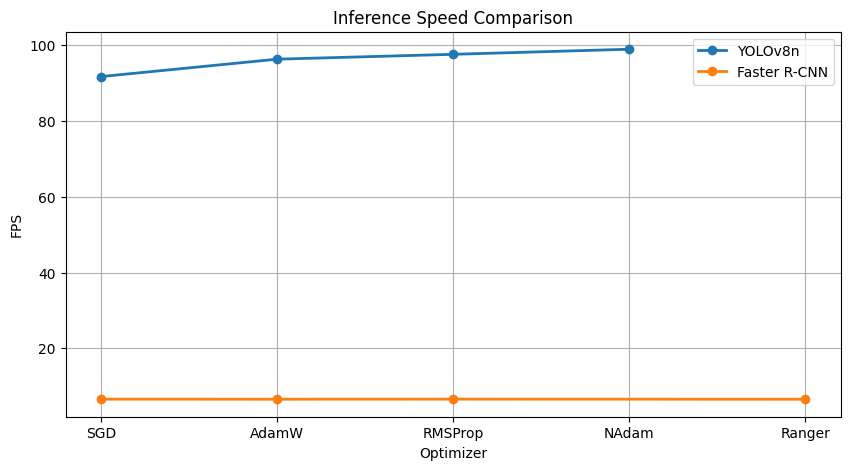

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for model in final_df["Model"].unique():

    d = final_df[final_df["Model"]==model]

    plt.plot(
        d["Optimizer"],
        d["FPS"],
        marker="o",
        linewidth=2,
        label=model
    )

plt.title("Inference Speed Comparison")
plt.xlabel("Optimizer")
plt.ylabel("FPS")
plt.grid(True)
plt.legend()

plt.show()

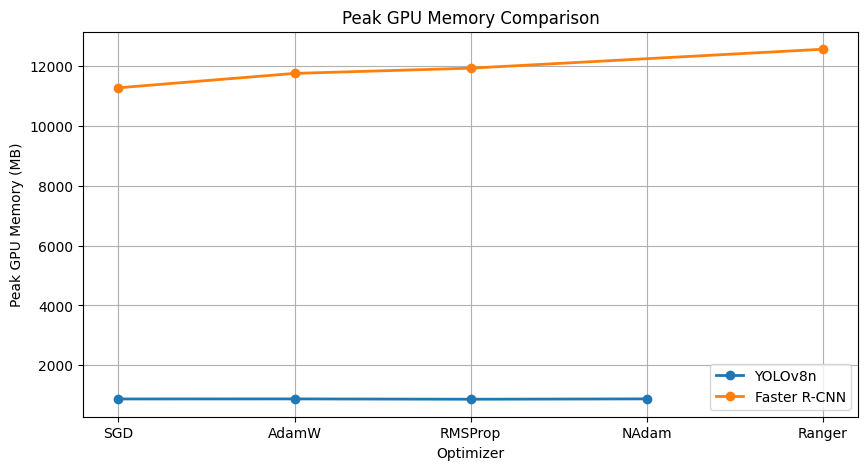

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for model in final_df["Model"].unique():

    d = final_df[final_df["Model"] == model]

    plt.plot(
        d["Optimizer"],
        d["GPU_Mem_MB"],
        marker="o",
        linewidth=2,
        label=model
    )

plt.title("Peak GPU Memory Comparison")
plt.xlabel("Optimizer")
plt.ylabel("Peak GPU Memory (MB)")
plt.grid(True)
plt.legend()

plt.show()


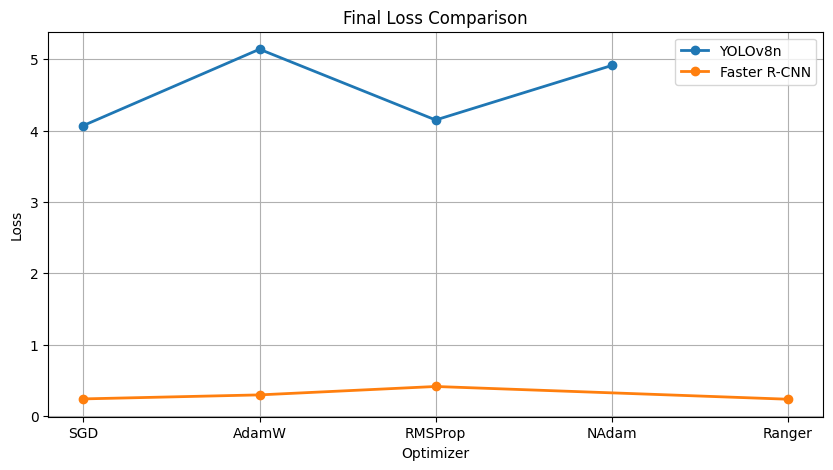

In [61]:
plt.figure(figsize=(10,5))

for model in final_df["Model"].unique():

    d = final_df[final_df["Model"]==model]

    plt.plot(
        d["Optimizer"],
        d["Final_Loss"],
        marker="o",
        linewidth=2,
        label=model
    )

plt.title("Final Loss Comparison")
plt.xlabel("Optimizer")
plt.ylabel("Loss")

plt.grid(True)
plt.legend()

plt.show()

In [62]:
print("="*50)
print("FINAL COMPARISON")
print("="*50)

print(f"""
YOLOv8n generally provides:

- Faster inference speed.
- Lower training time.
- Better detection accuracy (mAP).

Faster R-CNN generally provides:

- Higher computational cost.
- Slower inference.
- Competitive detection performance depending on the optimizer.

Optimizer performance should be selected according to the application:
- Real-time detection -> YOLO
- High-quality detection -> Faster R-CNN
""")

FINAL COMPARISON

YOLOv8n generally provides:

- Faster inference speed.
- Lower training time.
- Better detection accuracy (mAP).

Faster R-CNN generally provides:

- Higher computational cost.
- Slower inference.
- Competitive detection performance depending on the optimizer.

Optimizer performance should be selected according to the application:
- Real-time detection -> YOLO
- High-quality detection -> Faster R-CNN



In [63]:
final_df.to_csv(
    "results/final_comparison.csv",
    index=False
)

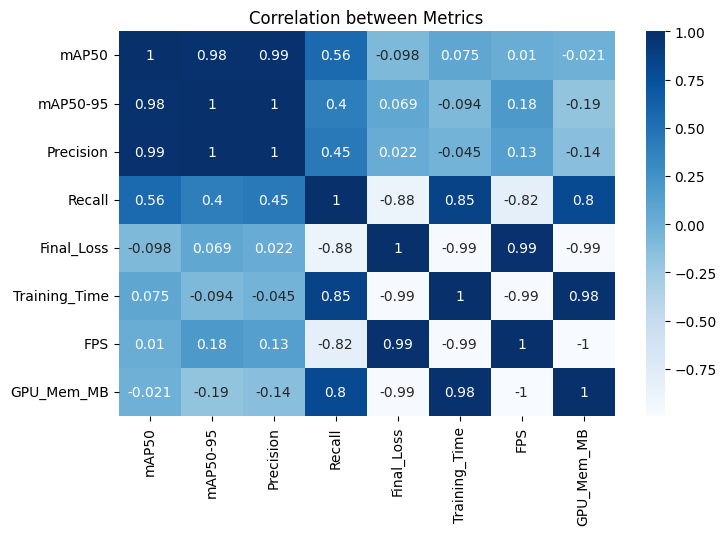

In [64]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.heatmap(
    final_df.select_dtypes("number").corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Correlation between Metrics")
plt.show()